# Category-Aware Pricing: Specialized Models

Exploring whether per-category models beat a single general model for Amazon product price prediction.

**Data:** ~20k training items from 8 Amazon categories via `Item.from_hub("tobenna/items_full")`  
**Categories:** Automotive, Electronics, Office_Products, Tools_and_Home_Improvement, Cell_Phones_and_Accessories, Toys_and_Games, Appliances, Musical_Instruments

---

## Step 1: Category Analysis & EDA

Understand how price distributions differ across product domains.

In [17]:
import os
import sys
sys.path.append(os.path.abspath("../.."))

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from pricer.items import Item

In [19]:
dataset = "inginia/items_lite_plus"

train, val, test = Item.from_hub(dataset)

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

data/train-00000-of-00001.parquet:   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Loaded 80,000 training items, 4,000 validation items, 4,000 test items


In [21]:
# Count items per category
category_counts = Counter(item.category for item in train)

# Sort by count descending
categories = [cat for cat, _ in category_counts.most_common()]
counts = [category_counts[cat] for cat in categories]

print("Items per category (sorted):")
for cat, count in category_counts.most_common():
    print(f"  {cat:<40} {count:>10,}")

Items per category (sorted):
  Electronics                                  18,780
  Tools_and_Home_Improvement                   18,229
  Automotive                                   16,871
  Toys_and_Games                               10,455
  Office_Products                               7,000
  Cell_Phones_and_Accessories                   3,628
  Musical_Instruments                           3,599
  Appliances                                    1,438


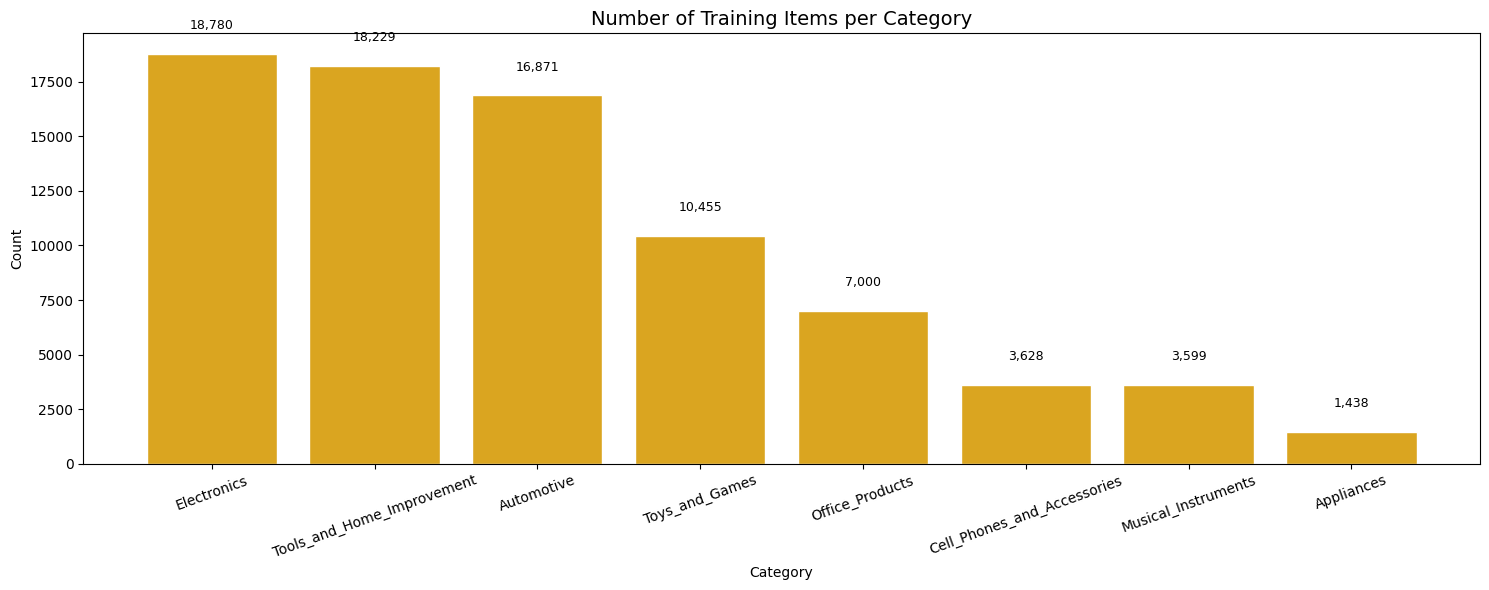

In [22]:
# Bar chart of category counts with count labels
fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.bar(categories, counts, color="goldenrod", edgecolor="white")

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Number of Training Items per Category", fontsize=14)
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

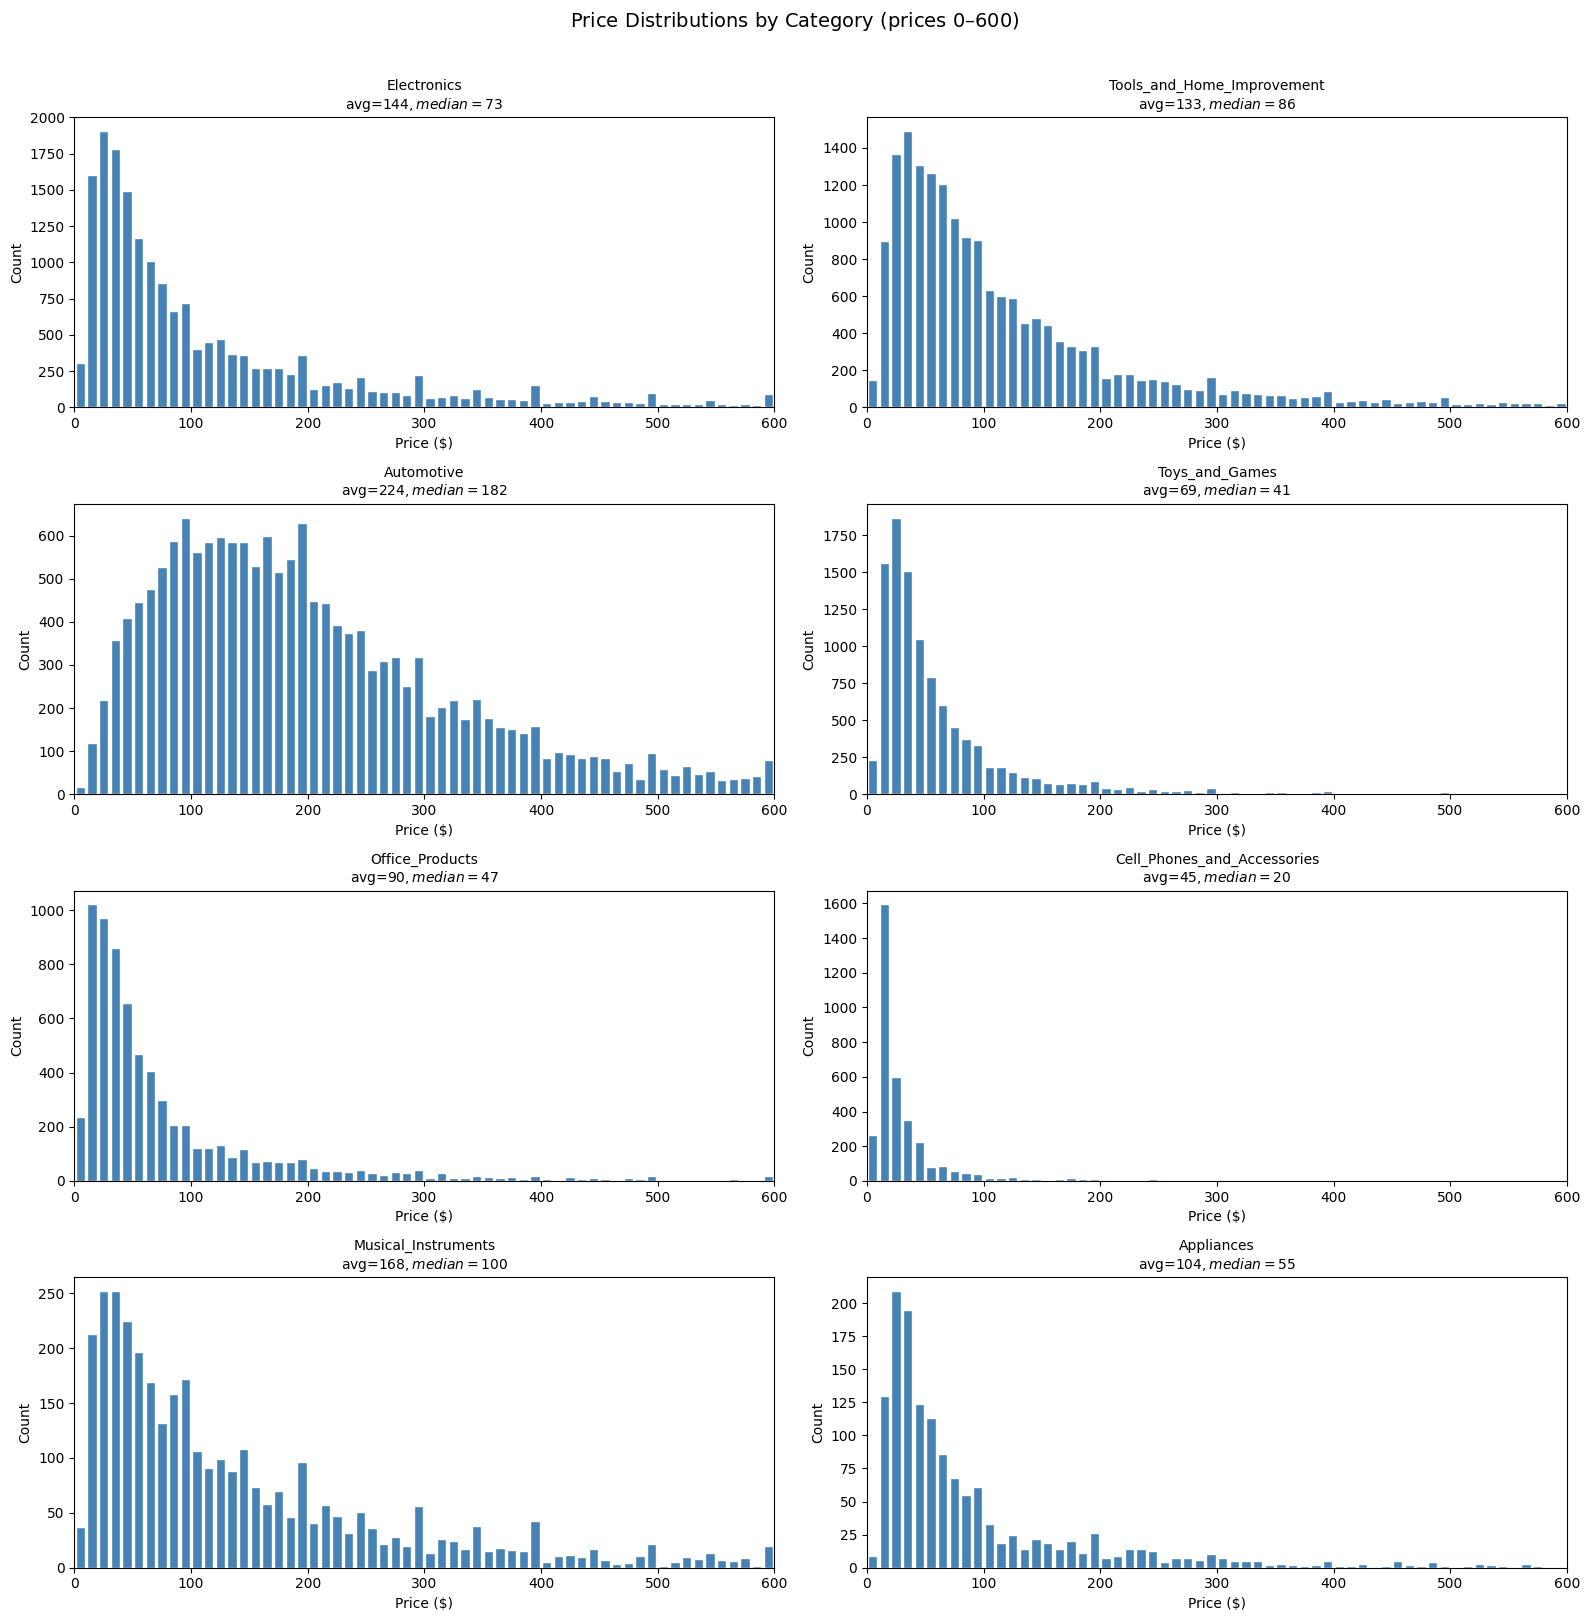

In [23]:
# Price histograms per category
n_cats = len(categories)
ncols = 2
nrows = (n_cats + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

items_by_category = {cat: [] for cat in categories}
for item in train:
    items_by_category[item.category].append(item)

for i, cat in enumerate(categories):
    prices = [item.price for item in items_by_category[cat]]
    avg_price = np.mean(prices)
    median_price = np.median(prices)
    axes[i].hist(prices, bins=range(0, 1000, 10), rwidth=0.8, color="steelblue", edgecolor="white")
    axes[i].set_title(f"{cat}\navg=${avg_price:.0f}, median=${median_price:.0f}", fontsize=10)
    axes[i].set_xlabel("Price ($)")
    axes[i].set_ylabel("Count")
    axes[i].set_xlim(0, 600)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Price Distributions by Category (prices $0–$600)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Key Observations

After running the EDA above, document findings here:

**Top categories by item count:**
- Eletronics, Tools and home improvements, Automotive

**Price distribution highlights:**
- Electronics and Appliances tend to have wider price ranges and higher medians — a $500 item is normal.
- Toys_and_Games and Cell_Phones_and_Accessories are skewed toward lower prices.
- Automotive has a large spread, potentially due to parts vs. accessories vs. equipment.

**Takeaway:** Categories have meaningfully different price priors and distributions — the key justification for building per-category specialized models in the steps ahead.

---

## Step 2: Single General XGBoost Baseline

Reproduce the general XGBoost model from day3 as a controlled baseline — all future per-category improvements are measured against this reference point.

In [24]:
import xgboost as xgb
from sklearn.feature_extraction.text import CountVectorizer
from pricer.evaluator import evaluate

In [25]:
# Fit vectorizer on training summaries
prices = [item.price for item in train]
documents = [item.summary for item in train]

np.random.seed(42)
vectorizer = CountVectorizer(max_features=2000, stop_words="english")
X_train = vectorizer.fit_transform(documents)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix: {X_train.shape}")

Vocabulary size: 2,000
Training matrix: (80000, 2000)


In [26]:
# Train the general XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=1000, random_state=42, n_jobs=4, learning_rate=0.1)
xgb_model.fit(X_train, prices)
print("Training complete.")

Training complete.


In [27]:
def general_xgb_pricer(item):
    x = vectorizer.transform([item.summary])
    return max(0, float(xgb_model.predict(x)[0]))

evaluate(general_xgb_pricer, test)

  0%|          | 0/200 [00:00<?, ?it/s]

$72 $67 $15 $7 $151 $170 $27 $36 $21 $58 $617 $196 $39 $105 $34 $22 $111 $90 $73 $32 $42 $4 $6 $68 $199 $149 $194 $38 $64 $63 $135 $95 $35 $29 $63 $223 $17 $68 $129 $32 $1 $53 $51 $57 $100 $48 $48 $17 $46 $20 $16 $103 $228 $19 $89 $24 $82 $91 $27 $27 $84 $20 $72 $22 $461 $203 $55 $3 $64 $151 $3 $30 $33 $138 $4 $71 $143 $7 $20 $70 $76 $34 $31 $38 $36 $34 $4 $49 $33 $120 $69 $62 $16 $26 $27 $30 $27 $22 $137 $237 $8 $43 $22 $63 $44 $20 $42 $249 $20 $77 $5 $39 $68 $37 $4 $63 $67 $25 $73 $57 $183 $88 $161 $4 $96 $85 $26 $76 $58 $62 $54 $37 $52 $29 $93 $23 $66 $7 $18 $115 $7 $150 $27 $77 $107 $44 $23 $286 $2 $53 $22 $145 $17 $33 $62 $122 $95 $7 $46 $38 $168 $12 $14 $10 $413 $2 $191 $49 $4 $10 $46 $0 $67 $41 $8 $108 $13 $4 $4 $40 $375 $11 $86 $15 $235 $45 $54 $12 $94 $59 $72 $62 $16 $7 $18 $46 $47 $26 $1 $45 

---

## Step 3: Per-Category XGBoost Models

Train a separate XGBoost model for each category, then compare per-category error against the general baseline on the same category slice.


In [30]:
import pandas as pd

# Split training data by category (reuse items_by_category from EDA if still in scope,
# but rebuild here to be self-contained)
train_by_cat = {cat: [] for cat in categories}
for item in train:
    train_by_cat[item.category].append(item)

test_by_cat = {cat: [] for cat in categories}
for item in test:
    test_by_cat[item.category].append(item)

print(f"{'Category':<45} {'Train':>8}  {'Test':>6}")
print("-" * 65)
for cat in categories:
    print(f"{cat:<45} {len(train_by_cat[cat]):>8,}  {len(test_by_cat[cat]):>6,}")

Category                                         Train    Test
-----------------------------------------------------------------
Electronics                                     18,780     918
Tools_and_Home_Improvement                      18,229     960
Automotive                                      16,871     864
Toys_and_Games                                  10,455     501
Office_Products                                  7,000     338
Cell_Phones_and_Accessories                      3,628     181
Musical_Instruments                              3,599     173
Appliances                                       1,438      65


In [31]:
cat_vectorizers = {}
cat_models = {}

for cat in categories:
    cat_items = train_by_cat[cat]
    cat_prices = [item.price for item in cat_items]
    cat_docs = [item.summary for item in cat_items]

    vec = CountVectorizer(max_features=1000, stop_words="english")
    X = vec.fit_transform(cat_docs)

    model = xgb.XGBRegressor(n_estimators=300, random_state=42, n_jobs=4, learning_rate=0.1)
    model.fit(X, cat_prices)

    cat_vectorizers[cat] = vec
    cat_models[cat] = model
    print(f"Trained {cat:<45} ({len(cat_items):,} items)")

Trained Electronics                                   (18,780 items)
Trained Tools_and_Home_Improvement                    (18,229 items)
Trained Automotive                                    (16,871 items)
Trained Toys_and_Games                                (10,455 items)
Trained Office_Products                               (7,000 items)
Trained Cell_Phones_and_Accessories                   (3,628 items)
Trained Musical_Instruments                           (3,599 items)
Trained Appliances                                    (1,438 items)


In [32]:
def make_cat_pricer(cat):
    """Return a pricer function bound to the given category's model."""
    vec = cat_vectorizers[cat]
    model = cat_models[cat]
    def pricer(item):
        x = vec.transform([item.summary])
        return max(0, float(model.predict(x)[0]))
    pricer.__name__ = f"cat_xgb_{cat}"
    return pricer

# Build comparison table: per-category MAE vs general model MAE on the same test slice
rows = []
for cat in categories:
    cat_test = test_by_cat[cat]
    if not cat_test:
        continue
    cat_pricer = make_cat_pricer(cat)
    cat_errors = [abs(cat_pricer(item) - item.price) for item in cat_test]
    gen_errors = [abs(general_xgb_pricer(item) - item.price) for item in cat_test]
    cat_mae = np.mean(cat_errors)
    gen_mae = np.mean(gen_errors)
    rows.append({
        "Category": cat,
        "N test": len(cat_test),
        "General MAE ($)": round(gen_mae, 2),
        "Per-Cat MAE ($)": round(cat_mae, 2),
        "Improvement ($)": round(gen_mae - cat_mae, 2),
    })

df_compare = pd.DataFrame(rows).sort_values("Improvement ($)", ascending=False)
print(df_compare.to_string(index=False))

                   Category  N test  General MAE ($)  Per-Cat MAE ($)  Improvement ($)
Cell_Phones_and_Accessories     181            32.77            19.82            12.96
                 Appliances      65            74.29            62.51            11.78
             Toys_and_Games     501            48.44            39.81             8.63
            Office_Products     338            55.33            49.78             5.55
        Musical_Instruments     173           107.93           102.53             5.41
                Electronics     918            74.97            72.48             2.49
                 Automotive     864            97.23            96.27             0.96
 Tools_and_Home_Improvement     960            78.94            79.14            -0.20


In [34]:
# Run evaluate() on each per-category model against its category-filtered test slice
for cat in categories:
    cat_test = test_by_cat[cat]
    if not cat_test:
        continue
    print(f"\n=== {cat} ===")
    evaluate(make_cat_pricer(cat), cat_test, size=len(cat_test))


=== Electronics ===


  0%|          | 0/918 [00:00<?, ?it/s]

$1 $4 $148 $59 $87 $41 $8 $99 $118 $126 $24 $265 $125 $140 $20 $96 $30 $90 $89 $3 $22 $56 $119 $15 $5 $6 $29 $66 $13 $204 $41 $189 $163 $198 $115 $79 $7 $18 $15 $126 $6 $160 $40 $44 $184 $13 $372 $14 $26 $15 $74 $30 $65 $8 $11 $31 $34 $157 $16 $51 $38 $17 $115 $13 $32 $55 $52 $101 $14 $28 $299 $31 $54 $82 $52 $17 $109 $90 $15 $55 $5 $49 $14 $34 $394 $82 $124 $54 $342 $40 $18 $2 $48 $23 $4 $291 $24 $45 $10 $40 $128 $29 $12 $441 $72 $3 $19 $64 $36 $31 $95 $72 $87 $42 $12 $31 $55 $63 $22 $22 $114 $5 $82 $18 $89 $15 $73 $177 $27 $40 $55 $83 $6 $68 $11 $113 $78 $54 $88 $14 $108 $18 $72 $30 $27 $74 $101 $122 $139 $18 $54 $57 $39 $72 $123 $75 $85 $55 $134 $53 $32 $3 $39 $46 $81 $257 $7 $29 $16 $20 $46 $5 $23 $109 $19 $72 $113 $212 $8 $40 $45 $33 $11 $33 $59 $8 $203 $28 $88 $218 $136 $22 $70 $38 $96 $58 $59 $67 $108 $31 $5 $9 $24 $64 $53 $22 $31 $9 $128 $33 $40 $65 $43 $9 $48 $67 $94 $23 $36 $14 $313 $67 $48 $63 $14 $207 $4 $12 $55 $22 $117 $115 $100 $5 $5 $12 $2 $6 $14 $18 $1 $57 $14 $21 $26 


=== Tools_and_Home_Improvement ===


  0%|          | 0/960 [00:00<?, ?it/s]

...

  0%|          | 0/173 [00:00<?, ?it/s]

$14 $535 $60 $222 $54 $26 $78 $24 $89 $154 $14 $54 $78 $1 $63 $50 $65 $42 $33 $2 $10 $7 $53 $137 $49 $15 $56 $581 $28 $50 $38 $52 $188 $204 $30 $62 $32 $449 $24 $55 $30 $97 $12 $9 $13 $10 $52 $180 $13 $25 $34 $26 $169 $129 $238 $82 $210 $39 $45 $45 $55 $138 $34 $133 $67 $16 $368 $271 $78 $9 $236 $125 $11 $140 $200 $79 $61 $7 $118 $210 $50 $90 $140 $21 $11 $394 $273 $33 $216 $122 $97 $150 $269 $535 $332 $23 $33 $43 $3 $272 $20 $106 $78 $118 $66 $206 $16 $390 $0 $144 $248 $58 $18 $153 $64 $21 $11 $88 $44 $79 $26 $256 $0 $359 $22 $131 $29 $60 $24 $100 $1 $186 $54 $328 $6 $69 $174 $16 $94 $70 $149 $5 $132 $59 $94 $31 $22 $119 $64 $54 $52 $203 $114 $115 $100 $75 $77 $41 $43 $263 $462 $68 $70 $31 $27 $148 $60 $4 $66 $116 $50 $167 $24 


=== Appliances ===


  0%|          | 0/65 [00:00<?, ?it/s]

$2 $14 $1 $41 $345 $21 $16 $296 $221 $157 $20 $22 $18 $24 $28 $14 $21 $18 $78 $3 $3 $3 $77 $11 $8 $41 $96 $124 $51 $9 $133 $17 $76 $27 $50 $17 $22 $39 $15 $10 $7 $33 $3 $100 $118 $42 $24 $28 $4 $153 $94 $5 $93 $311 $18 $43 $34 $80 $52 $1 $32 $52 $472 $48 $25 

---

## Step 4: Fine-Tune a Frontier Model for One Category

Fine-tune `gpt-4.1-nano` on training data for a single category and compare its accuracy against the XGBoost baselines from Step 3.

Call `fine_tune_category(cat)` with any category name to launch a job.  
Training takes ~5–15 minutes via the OpenAI API.

In [35]:
import json
from openai import OpenAI

openai_client = OpenAI()

In [37]:
def messages_for_ft(item):
    return [
        {"role": "user", "content": f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"},
        {"role": "assistant", "content": f"${item.price:.2f}"},
    ]

def make_jsonl(items):
    return "\n".join(json.dumps({"messages": messages_for_ft(item)}) for item in items)

def fine_tune_category(cat, train_size=500, val_size=50):
    """Fine-tune gpt-4.1-nano on training data for the given category.
    Returns the fine-tuning job ID.
    """
    import random as _random
    items = list(train_by_cat[cat])
    _random.shuffle(items)
    ft_train = items[:train_size]
    ft_val   = items[train_size:train_size + val_size]

    train_path = f"ft_train_{cat}.jsonl"
    val_path   = f"ft_val_{cat}.jsonl"

    with open(train_path, "w") as f:
        f.write(make_jsonl(ft_train))
    with open(val_path, "w") as f:
        f.write(make_jsonl(ft_val))

    with open(train_path, "rb") as f:
        train_file = openai_client.files.create(file=f, purpose="fine-tune")
    with open(val_path, "rb") as f:
        val_file = openai_client.files.create(file=f, purpose="fine-tune")

    job = openai_client.fine_tuning.jobs.create(
        training_file=train_file.id,
        validation_file=val_file.id,
        model="gpt-4.1-nano-2025-04-14",
        seed=42,
        hyperparameters={"n_epochs": 1, "batch_size": 1},
        suffix="pricer",
    )
    print(f"Fine-tuning job created: {job.id}")
    print(f"Training on {len(ft_train):,} items, validating on {len(ft_val):,} items")
    print(f"Monitor at: https://platform.openai.com/finetune/{job.id}")
    return job.id

In [38]:
FT_CATEGORY = "Electronics"  # change to any of the 8 categories

ft_job_id = fine_tune_category(FT_CATEGORY)

Fine-tuning job created: ftjob-msc3vJWAK816Jm9A5ARJufkI
Training on 500 items, validating on 50 items
Monitor at: https://platform.openai.com/finetune/ftjob-msc3vJWAK816Jm9A5ARJufkI


In [44]:
# Re-run this cell to check progress
job = openai_client.fine_tuning.jobs.retrieve(ft_job_id)
print(f"Status : {job.status}")
print(f"Model  : {job.fine_tuned_model}")

for event in openai_client.fine_tuning.jobs.list_events(ft_job_id, limit=5).data:
    print(f"  {event.message}")

Status : succeeded
Model  : ft:gpt-4.1-nano-2025-04-14:personal:pricer:DHpu7hmE
  The job has successfully completed
  Usage policy evaluations completed, model is now enabled for sampling
  Moderation checks for snapshot ft:gpt-4.1-nano-2025-04-14:personal:pricer:DHpu7hmE passed.
  Evaluating model against our usage policies
  New fine-tuned model created


In [45]:
fine_tuned_model_name = openai_client.fine_tuning.jobs.retrieve(ft_job_id).fine_tuned_model

def ft_pricer(item):
    response = openai_client.chat.completions.create(
        model=fine_tuned_model_name,
        messages=[{"role": "user", "content": f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"}],
        max_tokens=7,
    )
    return response.choices[0].message.content

ft_pricer.__name__ = f"fine_tuned_{FT_CATEGORY}"

evaluate(ft_pricer, test_by_cat[FT_CATEGORY], size=len(test_by_cat[FT_CATEGORY]))

  0%|          | 0/918 [00:00<?, ?it/s]

$5 $30 $71 $30 $111 $60 $4 $115 $347 $5 $8 $390 $56 $21 $8 $10 $30 $516 $35 $43 $6 $2 $142 $1 $17 $19 $5 $29 $248 $221 $78 $6 $410 $20 $120 $51 $32 $15 $50 $37 $25 $150 $218 $17 $137 $41 $104 $11 $73 $43 $74 $141 $449 $4 $65 $3 $29 $19 $23 $147 $15 $19 $3 $45 $16 $11 $20 $11 $12 $95 $64 $32 $35 $40 $30 $15 $0 $34 $3 $42 $16 $6 $11 $176 $385 $55 $31 $130 $394 $102 $6 $4 $53 $16 $66 $350 $16 $35 $254 $20 $8 $6 $20 $281 $3 $23 $96 $90 $7 $13 $135 $250 $97 $44 $2 $65 $40 $34 $35 $222 $6 $6 $331 $13 $31 $10 $540 $138 $11 $37 $18 $152 $5 $122 $46 $135 $14 $130 $4 $20 $16 $20 $49 $41 $135 $80 $106 $3 $218 $3 $83 $26 $11 $64 $5 $85 $29 $1 $56 $24 $0 $6 $398 $30 $23 $1361 $10 $40 $35 $5 $94 $34 $8 $4 $2 $144 $0 $134 $2 $65 $9 $21 $130 $25 $19 $2 $56 $96 $3 $164 $70 $603 $443 $29 $240 $18 $18 $19 $620 $12 $4 $59 $15 $7 $1 $22 $70 $32 $141 $57 $152 $7 $135 $51 $36 $6 $10 $20 $26 $391 $277 $27 $79 $12 $50 $211 $3 $20 $10 $68 $145 $80 $175 $31 $9 $31 $23 $60 $3 $21 $24 $20 $7 $149 $40 $52 $150 $28 

In [48]:
import re
import plotly.graph_objects as go

def parse_price(raw):
    """Extract a float from any LLM response string, e.g. '$29.99', 'Price: $29', '29\n'."""
    if isinstance(raw, (int, float)):
        return float(raw)
    match = re.search(r"[-+]?\d*\.\d+|\d+", str(raw).replace(',', ''))
    return float(match.group()) if match else 0.0

cat_test = test_by_cat[FT_CATEGORY]

model_mae = {
    "General XGBoost":  float(np.mean([abs(general_xgb_pricer(item) - item.price) for item in cat_test])),
    "Per-Cat XGBoost":  float(np.mean([abs(make_cat_pricer(FT_CATEGORY)(item) - item.price) for item in cat_test])),
    "Fine-tuned LLM":   float(np.mean([abs(parse_price(ft_pricer(item)) - item.price) for item in cat_test])),
}

for name, mae in model_mae.items():
    print(f"  {name:<20} MAE = ${mae:.2f}")

fig = go.Figure(go.Bar(
    x=list(model_mae.keys()),
    y=list(model_mae.values()),
    text=[f"${v:.2f}" for v in model_mae.values()],
    textposition="outside",
    marker_color=["steelblue", "goldenrod", "firebrick"],
))
fig.update_layout(
    title=f"MAE Comparison — {FT_CATEGORY}",
    xaxis_title="Model",
    yaxis_title="Mean Absolute Error ($)",
    width=700,
    height=450,
    template="plotly_white",
)
fig.show()

  General XGBoost      MAE = $74.97
  Per-Cat XGBoost      MAE = $72.48
  Fine-tuned LLM       MAE = $78.55
